In [56]:
import sys
import math
import matplotlib.pyplot as plt
import pandas as pd
import heapq


In [57]:
def plotar_agm(coords, agm, title, custo):
    plt.figure(figsize=(18, 8))

    for i, (_, x, y) in enumerate(coords):
        plt.scatter(x, y, s=80)
        plt.text(x, y, str(i + 1), fontsize=12)

    for peso, vertice, pai in agm:
        _, x1, y1 = coords[pai - 1]
        _, x2, y2 = coords[vertice - 1]

        plt.plot([x1, x2], [y1, y2], linewidth=2)

        plt.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            str(peso),
            fontsize=10
        )

    plt.title(f"{title} - Custo: {custo}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

    plt.show()

def plotar_grafo(coords, matriz):
    plt.figure(figsize=(18, 8))

    n = len(coords)

    for i in range(n):
        _, x1, y1 = coords[i]

        for j in range(i + 1, n):

            peso = matriz[i][j]

            if peso != 0:
                _, x2, y2 = coords[j]

                plt.plot(
                    [x1, x2],
                    [y1, y2],
                    alpha=0.3
                )

                xm = (x1 + x2) / 2
                ym = (y1 + y2) / 2

                plt.text(
                    xm,
                    ym,
                    str(peso),
                    fontsize=7
                )

    for i, (_, x, y) in enumerate(coords):
        plt.scatter(x, y, s=100)

        plt.text(
            x,
            y,
            str(i + 1),
            fontsize=12,
            verticalalignment='bottom',
            horizontalalignment='right'
        )

    plt.title("Grafo Completo")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)

    plt.show()

def plotar_ciclo(coords, ciclo, custo):

    plt.figure(figsize=(18, 8))

    for id_, x, y in coords:
        plt.scatter(x, y, s=80)
        plt.text(x, y, str(id_), fontsize=12)

    for i in range(len(ciclo) - 1):

        v1 = ciclo[i]
        v2 = ciclo[i + 1]

        _, x1, y1 = coords[v1 - 1]
        _, x2, y2 = coords[v2 - 1]

        plt.plot([x1, x2], [y1, y2])

    plt.title(f"Ciclo Hamiltoniano - Custo {custo:.2f}") 
    plt.show()


In [58]:
def ler_tsp_arquivo(caminho_arquivo):
    coords = []
    lendo = False

    with open(caminho_arquivo, 'r') as f:
        for linha in f:
            linha = linha.strip()

            if linha == "NODE_COORD_SECTION":
                lendo = True
                continue

            if linha == "EOF":
                break

            if lendo:
                partes = linha.split()
                id = int(partes[0])
                x = float(partes[1])
                y = float(partes[2])
                coords.append((id, x, y))

    return coords


In [59]:
def calcular_distancia(cidade1, cidade2):
    _, xi, yi = cidade1
    _, xj, yj = cidade2

    dist = math.sqrt((xi - xj)**2 + (yi - yj)**2)
    return math.floor(0.5 + dist)

In [60]:
def criar_matriz_distancias(coords):
    n = len(coords)

    matriz = [[0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        for j in range(n):
            if i != j:
                matriz[i][j] = calcular_distancia(coords[i], coords[j])

    return matriz

def imprimir_matriz_com_ids(coords, matriz):
    ids = [cidade[0] for cidade in coords]

    print("     ", end="")
    for id_cidade in ids:
        print(f"{id_cidade:6}", end="")
    print()

    for i, linha in enumerate(matriz):
        print(f"{ids[i]:5}", end="")
        for valor in linha:
            print(f"{valor:6}", end="")
        print()

In [61]:

# Prim_matriz Adaptado de: https://www.programiz.com/dsa/prim-algorithm
def prim_matriz(grafo, inicio=0):
    n = len(grafo)

    selecionado = [False] * n
    selecionado[inicio] = True

    agm = []
    custo_total = 0

    while len(agm) < n - 1:
        menor_peso = float("inf")
        origem = -1
        destino = -1

        # Percorre todos os vértices já selecionados
        for i in range(n):
            if selecionado[i]:
                # Procura a menor aresta para um vértice ainda não selecionado
                for j in range(n):
                    if not selecionado[j] and grafo[i][j] != 0:
                        if grafo[i][j] < menor_peso:
                            menor_peso = grafo[i][j]
                            origem = i
                            destino = j

        if destino == -1:
            raise ValueError("O grafo é desconexo. Não é possível gerar uma AGM.")

        selecionado[destino] = True
        agm.append(( menor_peso, destino + 1, origem + 1))
        custo_total += menor_peso

    return agm, custo_total

In [62]:
#Emparelhamento Perfeito

def encontrar_vertices_impares(agm, n):
    grau = [0] * n

    for peso, vertice, pai in agm:
        grau[vertice - 1] += 1
        grau[pai - 1] += 1

    impares = []

    for i in range(n):
        if grau[i] % 2 != 0:
            impares.append(i + 1)

    return impares


def emparelhamento_perfeito_minimo(impares, matriz):
    melhor_pares = []
    melhor_custo = float("inf")

    def menor_custo(vertices_restantes, pares_atual, custo_atual):
        nonlocal melhor_pares, melhor_custo

        if not vertices_restantes:
            if custo_atual < melhor_custo:
                melhor_custo = custo_atual
                melhor_pares = pares_atual.copy()
            return

        # poda simples
        if custo_atual >= melhor_custo:
            return

        v = vertices_restantes[0]

        for i in range(1, len(vertices_restantes)):
            u = vertices_restantes[i]

            peso = matriz[v - 1][u - 1]

            novos_restantes = (
                vertices_restantes[1:i] +
                vertices_restantes[i + 1:]
            )

            pares_atual.append((peso,v, u))
            menor_custo(novos_restantes, pares_atual, custo_atual + peso)
            pares_atual.pop()

    if len(impares) % 2 != 0:
        raise ValueError("A quantidade de vértices ímpares deve ser par.")

    menor_custo(impares, [], 0)

    return melhor_pares, melhor_custo



In [63]:
def construir_multigrafo(arestas, n):

    grafo = {i: [] for i in range(1, n + 1)}

    for peso, u, v in arestas:

        grafo[u].append(v)
        grafo[v].append(u)

    return grafo


def ciclo_euleriano(grafo):
    g = {v: sorted(vizinhos, reverse=True) for v, vizinhos in grafo.items()}
    
    pilha = [1]
    ciclo = []

    while pilha:
        topo = pilha[-1]
        
        if g[topo]:
            vizinho = g[topo].pop()
            g[vizinho].remove(topo)
            pilha.append(vizinho)
        else:
            ciclo.append(pilha.pop())
    
    ciclo.reverse()
    
    return ciclo

def ciclo_hamiltoniano(ciclo_euleriano):

    visitados = set()

    hamiltoniano = []

    for v in ciclo_euleriano:

        if v not in visitados:

            hamiltoniano.append(v)

            visitados.add(v)

    hamiltoniano.append(hamiltoniano[0])

    return hamiltoniano

def calcular_custo(ciclo, matriz):

    custo = 0

    for i in range(len(ciclo) - 1):

        u = ciclo[i]
        v = ciclo[i + 1]

        custo += matriz[u - 1][v - 1]

    return custo


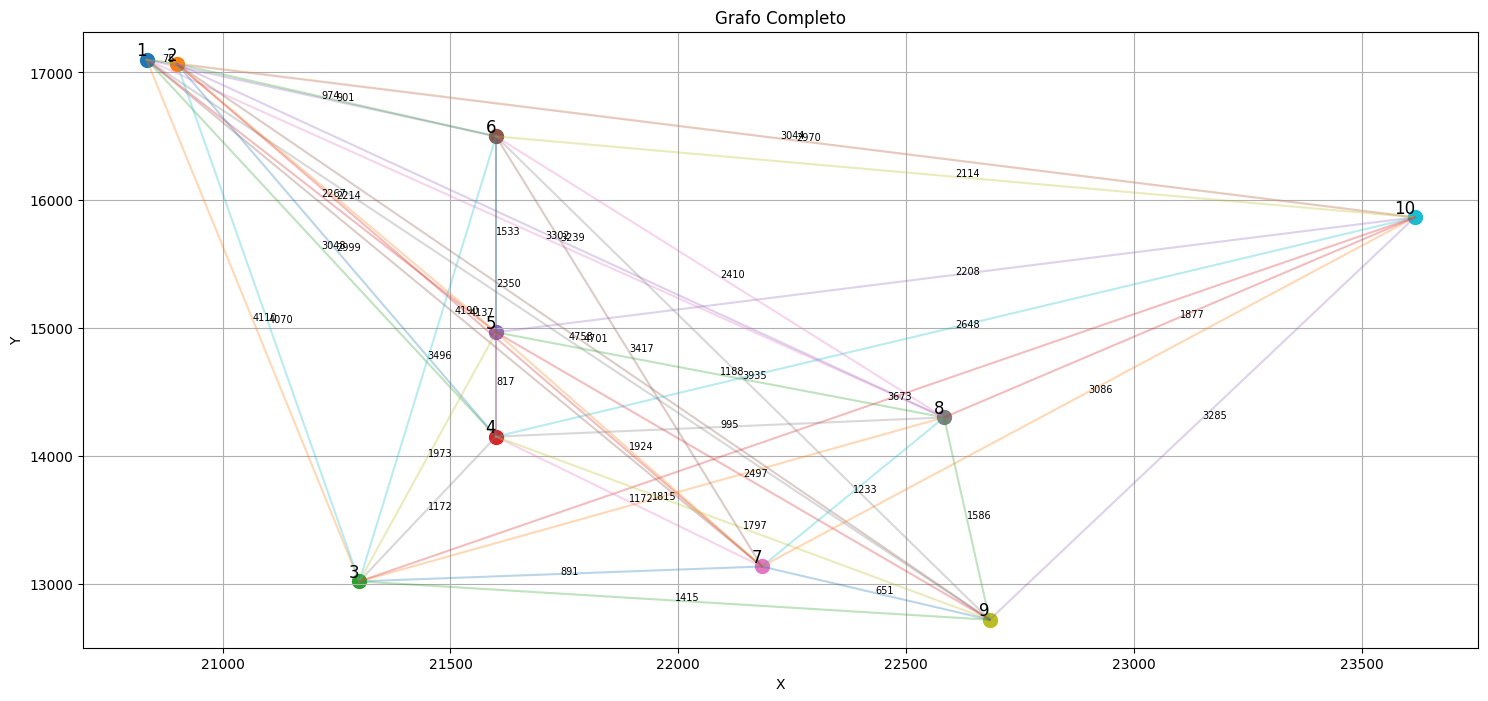

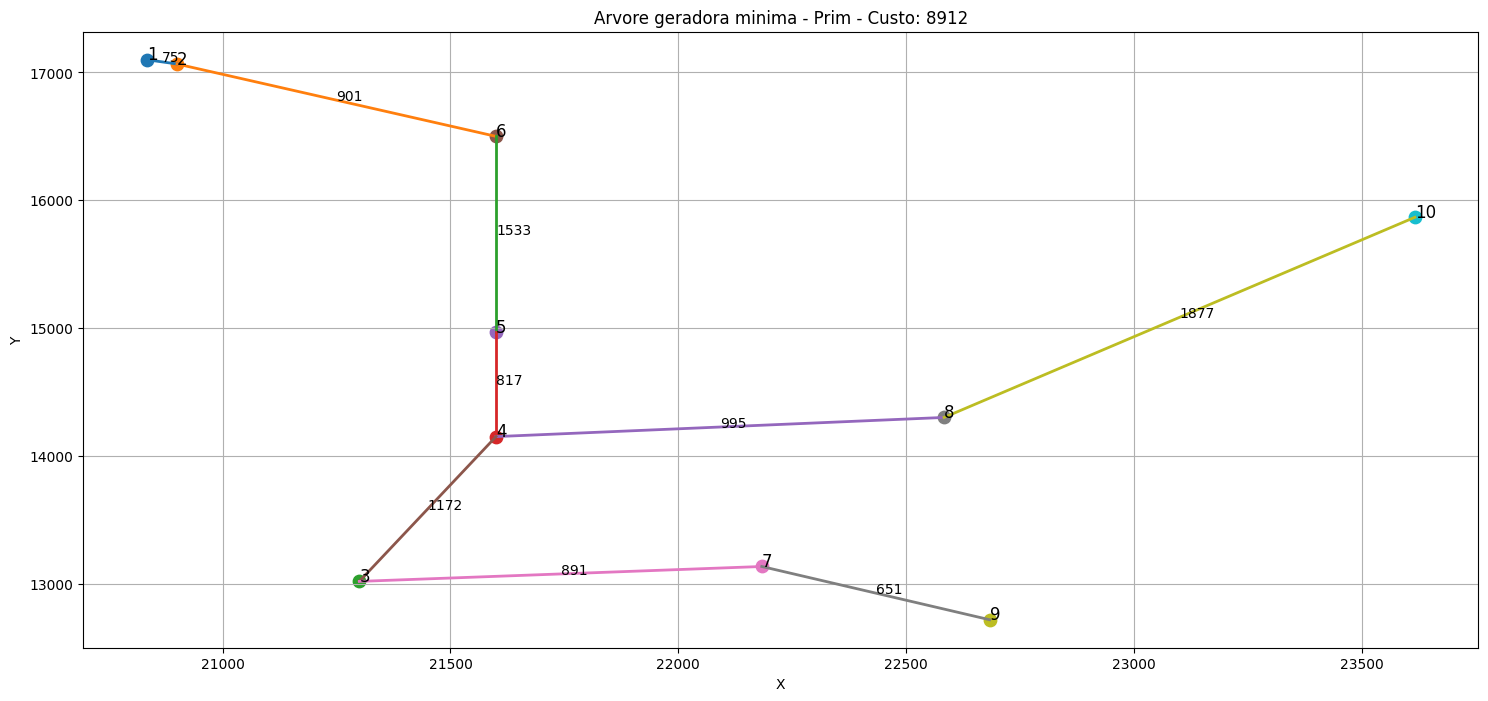

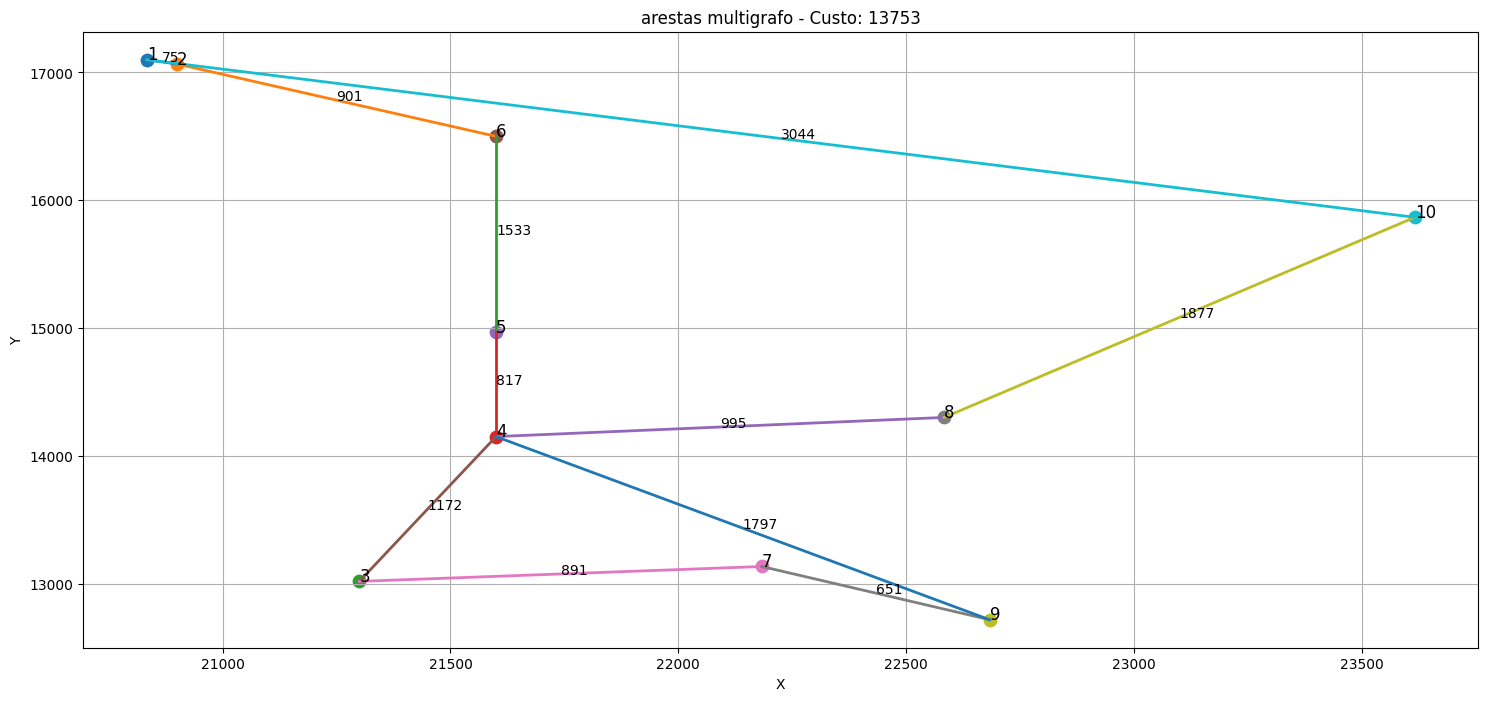

{1: [2, 10], 2: [1, 6], 3: [4, 7], 4: [5, 8, 3, 9], 5: [6, 4], 6: [2, 5], 7: [3, 9], 8: [4, 10], 9: [7, 4], 10: [8, 1]}


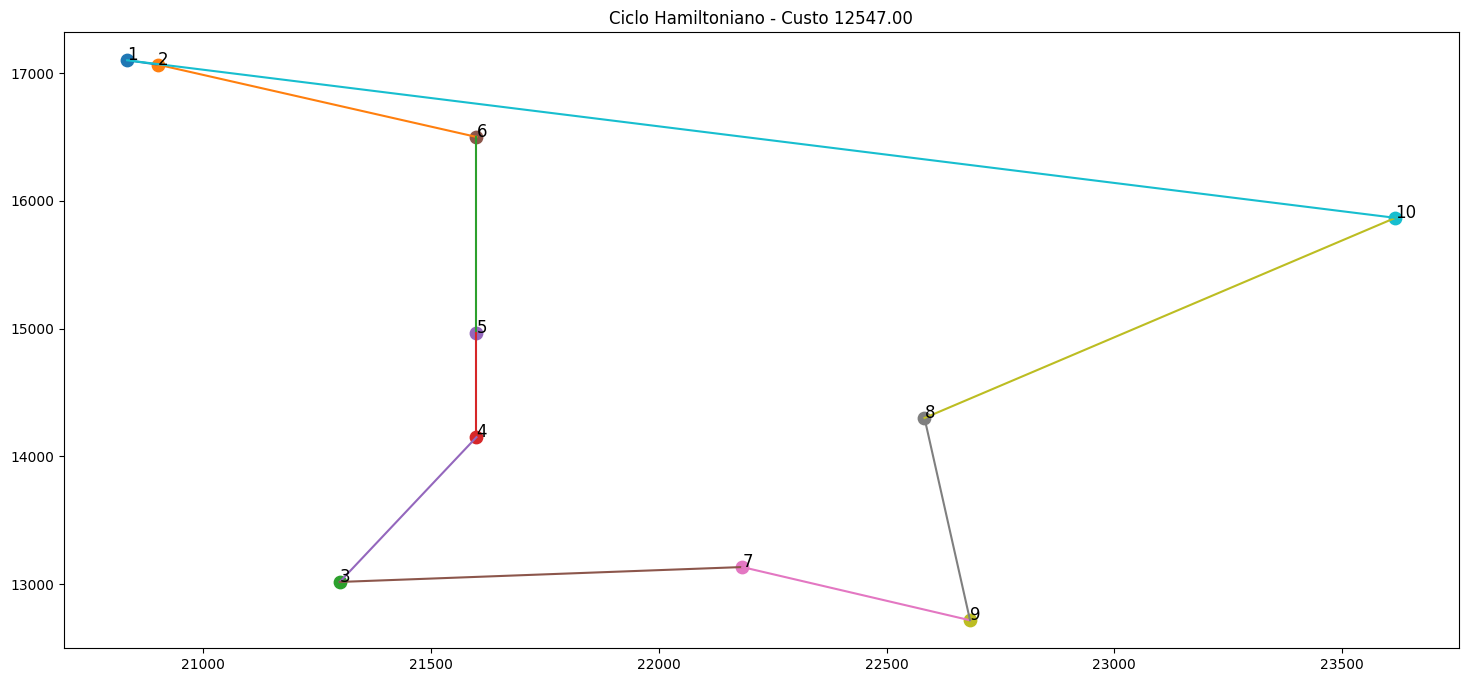

Custo ótimo: 27603
Custo AGM: 8912
Custo emparelhamento: 4841
Custo Christofides: 12547
Razão: 0.4545520414447705


In [ ]:
coords = ler_tsp_arquivo("tsp10.tsp")
matriz = criar_matriz_distancias(coords)

plotar_grafo(coords,matriz)

agm_matriz, custo_agm = prim_matriz(matriz)

plotar_agm(coords, agm_matriz, "Arvore geradora minima - Prim", custo_agm)

impares = encontrar_vertices_impares(agm_matriz, len(matriz))

emparelhamento, custo_emp = emparelhamento_perfeito_minimo(impares, matriz)

arestas_multigrafo = agm_matriz + emparelhamento

plotar_agm(coords, arestas_multigrafo, "arestas multigrafo", (custo_emp+custo_agm))

grafo = construir_multigrafo(arestas_multigrafo, len(matriz))

ciclo_euler = ciclo_euleriano(grafo)

custo = calcular_custo(ciclo_euler, matriz)

hamiltoniano = ciclo_hamiltoniano(ciclo_euler)

custo_final = calcular_custo(hamiltoniano, matriz)

plotar_ciclo(coords, hamiltoniano, custo_final)

print("Custo ótimo:", 27603) #precisa justar
print("Custo AGM:", custo_agm)
print("Custo emparelhamento:", custo_emp)
print("Custo Christofides:", custo_final)
print("Razão:", custo_final / 27603) #precisa ajustar